# 00 — Public Dataset Acquisition: Yost 2019 BCC TIL + Caushi 2021 NSCLC

This notebook downloads and prepares **two public human TIL datasets** with paired scRNA-seq and TCR clonotype data:

| # | Dataset | GEO | Cancer | n cells | Ground truth |
|---|---------|-----|--------|---------|-------------|
| A | **Yost et al. 2019** | [GSE123813](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE123813) | Basal cell carcinoma (BCC) | ~53k | CD8+CD39+ exhausted TIL, pre/post anti-PD-1 |
| B | **Caushi et al. 2021** | [GSE176021](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE176021) | NSCLC | ~8k CD8+ | MANAFEST-validated neoantigen-specific TCRs |

**Why these two?**

- **Yost 2019 (BCC)** is the canonical exhausted-TIL dataset and the tutorial dataset used by `scRepertoire`. CD8+CD39+ clonotypes are experimentally enriched for tumour reactivity (Simoni et al. 2018). We use this as the **primary demo** for NB01–NB03 (scRNA-seq + exhaustion scoring).
- **Caushi 2021 (NSCLC)** provides **MANAFEST-validated neoantigen-specific TCR clonotypes** — experimentally confirmed tumour-reactive TCRs at single-clone resolution. This becomes the **ground-truth label set** for training/evaluating the Random Forest in NB04.

**Outputs of this notebook:**
```
data/yost2019_bcc_query.rds          # Seurat object: BCC TIL scRNA-seq (NB01-03 demo)
data/yost2019_bcc_tcr.rds            # TCR clonotype assignments for BCC TIL
data/caushi2021_cd8_annotated.rds    # Caushi CD8 Seurat object with MANAFEST labels
data/caushi2021_ranked_clonotypes.csv # clonotype table with is_reactive ground truth
```

> **Data access:** All data are freely available (no dbGaP access required). Raw FASTQ files are available via SRA (SRP173389, SRP316408) but we use GEO supplementary processed files only.

In [1]:
# Papermill parameter cell
data_dir   <- "data"
cache_dir  <- "data/raw_downloads"   # raw GEO files cached here
use_yost   <- TRUE   # download & prepare Yost 2019 BCC
use_caushi <- TRUE   # download & prepare Caushi 2021 NSCLC
n_hvg      <- 2000L
random_seed <- 42L

# Patient-based LOO split: leave this patient out as query, rest = reference.
# Set to "" to pick one patient randomly (reproducible via random_seed).
query_patient <- ""

# Output paths (overridable by papermill / run_cca_pipeline.sh)
output_query             <- "data/cca/query.rds"
output_reference         <- "data/cca/reference.rds"
output_tcr               <- "data/cca/yost2019_bcc_tcr.rds"
output_caushi_clonotypes <- "data/caushi2021_ranked_clonotypes.csv"


In [2]:
# Parameters
raw_counts_path = "data/raw_downloads/GSE123813_bcc_scRNA_counts.txt.gz"
raw_metadata_path = "data/raw_downloads/GSE123813_bcc_tcell_metadata.txt.gz"
raw_tcr_path = "data/raw_downloads/GSE123813_bcc_tcr.txt.gz"
caushi_cd8_gz = "data/raw_downloads/GSE176021_CD8_annotations.rds.gz"
output_query = "data/cca/query_su001.rds"
output_reference = "data/cca/reference_no_su001.rds"
output_tcr = "data/cca/yost2019_bcc_tcr.rds"
output_caushi_clonotypes = "data/caushi2021_ranked_clonotypes.csv"
query_patient = "su001"
n_dims = 30


In [3]:
suppressPackageStartupMessages({
  library(Seurat)
  library(dplyr)
  library(ggplot2)
  library(patchwork)
  library(Matrix)
  library(data.table)
})
set.seed(random_seed)
options(repr.plot.width = 9, repr.plot.height = 4)  # compact figures

dir.create(data_dir,  showWarnings = FALSE, recursive = TRUE)
dir.create(cache_dir, showWarnings = FALSE, recursive = TRUE)

# Helper: download with caching
cached_download <- function(url, dest) {
  if (!file.exists(dest)) {
    cat(sprintf("Downloading %s ...\n", basename(dest)))
    download.file(url, destfile = dest, method = "curl", quiet = FALSE)
  } else {
    cat(sprintf("Cached: %s\n", basename(dest)))
  }
  dest
}

cat(sprintf("Seurat %s | R %s.%s\n",
            packageVersion("Seurat"),
            R.version$major, R.version$minor))

Seurat 5.5.0 | R 4.4.3


## Part A — Yost et al. 2019 BCC (GSE123813)

**Paper:** Yost KE, Satpathy AT, Wells DK, et al. *Clonal replacement of tumor-specific T cells following PD-1 blockade.* Nat Med 2019;25:1251–1259. PMID: 31359002

**Files used:**
- `GSE123813_bcc_scRNA_counts.txt.gz` — gene × cell count matrix for BCC T cells
- `GSE123813_bcc_tcell_metadata.txt.gz` — per-cell metadata (cell type, sample, timepoint)
- `GSE123813_bcc_tcr.txt.gz` — TCR α/β CDR3 sequences + clone size per cell

**Biological context:** 6 BCC patients, tumour T cells sorted (CD45+CD3+), 10x 5' scRNA-seq + TCR-seq, pre- and post-anti-PD-1. CD8+CD39+ cells are tumour-reactive exhausted TIL (ENTPD1 = CD39).

In [4]:
if (use_yost) {
  geo_base <- "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE123nnn/GSE123813/suppl"

  counts_gz <- cached_download(
    sprintf("%s/GSE123813_bcc_scRNA_counts.txt.gz", geo_base),
    file.path(cache_dir, "GSE123813_bcc_scRNA_counts.txt.gz")
  )
  meta_gz <- cached_download(
    sprintf("%s/GSE123813_bcc_tcell_metadata.txt.gz", geo_base),
    file.path(cache_dir, "GSE123813_bcc_tcell_metadata.txt.gz")
  )
  tcr_gz <- cached_download(
    sprintf("%s/GSE123813_bcc_tcr.txt.gz", geo_base),
    file.path(cache_dir, "GSE123813_bcc_tcr.txt.gz")
  )
  cat("All Yost 2019 BCC files downloaded.\n")
}

Cached: GSE123813_bcc_scRNA_counts.txt.gz
Cached: GSE123813_bcc_tcell_metadata.txt.gz
Cached: GSE123813_bcc_tcr.txt.gz
All Yost 2019 BCC files downloaded.


In [5]:
if (use_yost) {
  cat("Reading count matrix...\n")

  # --- Step 1: read header line to get exact cell-barcode column names ---
  # fread header-detection misbehaves on this wide gzipped file;
  # reading the first line manually is the reliable approach.
  con        <- gzcon(file(counts_gz, "rb"))
  hdr_line   <- readLines(con, n = 1L)
  close(con)
  cell_names <- strsplit(hdr_line, "\t", fixed = TRUE)[[1]]
  n_cells    <- length(cell_names)
  cat(sprintf("Header: %d cell barcodes, e.g. %s\n", n_cells, cell_names[1]))

  # --- Step 2: read data rows (skip header) ---
  counts_raw <- data.table::fread(counts_gz, skip = 1L, header = FALSE,
                                   data.table = TRUE)
  gene_names <- counts_raw[[1]]
  n_genes    <- length(gene_names)
  counts_raw[[1]] <- NULL          # remove gene-name column
  cat(sprintf("Count matrix: %d genes x %d cells\n", n_genes, ncol(counts_raw)))

  # sanity check
  stopifnot(ncol(counts_raw) == n_cells)

  # --- Step 3: build sparse matrix column-by-column to avoid OOM ---
  cat("Building sparse matrix (column-by-column, avoids OOM)...\n")
  est_nnz  <- n_cells * 5000L
  i_idx    <- integer(est_nnz)
  j_idx    <- integer(est_nnz)
  x_val    <- numeric(est_nnz)
  ptr      <- 0L
  for (j in seq_len(n_cells)) {
    col_vals <- counts_raw[[j]]
    nz       <- which(col_vals > 0L)
    n_nz     <- length(nz)
    if (n_nz > 0L) {
      range          <- (ptr + 1L):(ptr + n_nz)
      i_idx[range]   <- nz
      j_idx[range]   <- j
      x_val[range]   <- col_vals[nz]
      ptr            <- ptr + n_nz
    }
    if (j %% 2000L == 0L)
      cat(sprintf("  %d/%d cells processed...\r", j, n_cells))
  }
  cat("\n")
  counts_sparse <- Matrix::sparseMatrix(
    i         = i_idx[seq_len(ptr)],
    j         = j_idx[seq_len(ptr)],
    x         = x_val[seq_len(ptr)],
    dims      = c(n_genes, n_cells),
    dimnames  = list(gene_names, cell_names)
  )
  rm(counts_raw, i_idx, j_idx, x_val); gc()
  cat(sprintf("Sparse matrix: %d genes x %d cells, %.1f%% non-zero\n",
              nrow(counts_sparse), ncol(counts_sparse),
              100 * length(counts_sparse@x) / prod(dim(counts_sparse))))

  # --- Step 4: Read metadata (cell.id column IS the row identifier) ---
  meta_yost <- read.table(meta_gz, sep = "\t", header = TRUE,
                           stringsAsFactors = FALSE)
  rownames(meta_yost) <- meta_yost$cell.id
  meta_yost$cell.id   <- NULL
  cat(sprintf("Metadata: %d cells, columns: %s\n",
              nrow(meta_yost), paste(colnames(meta_yost), collapse = ", ")))

  # --- Step 5: Subset to cells present in both ---
  common_cells  <- intersect(colnames(counts_sparse), rownames(meta_yost))
  cat(sprintf("Cells in both matrix and metadata: %d\n", length(common_cells)))
  stopifnot(length(common_cells) > 0)
  counts_sparse <- counts_sparse[, common_cells]
  meta_yost     <- meta_yost[common_cells, , drop = FALSE]
}

Reading count matrix...
Header: 53030 cell barcodes, e.g. bcc.su001.pre.tcell_AAACCTGCAGATCGGA
Count matrix: 23309 genes x 53030 cells
Building sparse matrix (column-by-column, avoids OOM)...
  52000/53030 cells processed...
Sparse matrix: 23309 genes x 53030 cells, 8.1% non-zero
Metadata: 33106 cells, columns: patient, treatment, cluster, UMAP1, UMAP2
Cells in both matrix and metadata: 33106


In [6]:
if (use_yost) {
  # Build Seurat object
  yost <- CreateSeuratObject(
    counts   = counts_sparse,
    meta.data = meta_yost,
    project  = "Yost2019_BCC",
    min.cells = 3, min.features = 100
  )
  rm(counts_sparse); gc()

  cat(sprintf("Seurat object: %d cells x %d genes\n", ncol(yost), nrow(yost)))
  cat("Cell type distribution (from metadata):\n")
  if ("cluster" %in% colnames(yost@meta.data))
    print(table(yost$cluster))
  if ("patient" %in% colnames(yost@meta.data))
    print(table(yost$patient))
}

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


Seurat object: 33106 cells x 17865 genes
Cell type distribution (from metadata):

   CD8_act    CD8_eff     CD8_ex CD8_ex_act    CD8_mem      Naive        Tfh 
      3888        775       1264        302       6135       5197       2805 
      Th17      Tregs 
      8210       4530 

su001 su002 su003 su004 su005 su006 su007 su008 su009 su010 su012 
 4959   274   219   875  3464  3805  1668  4868  9047   626  3301 


In [7]:
if (use_yost) {
  # Read TCR table
  tcr_yost <- read.table(tcr_gz, sep = "\t", header = TRUE,
                          stringsAsFactors = FALSE)
  cat(sprintf("TCR table: %d rows, columns: %s\n",
              nrow(tcr_yost), paste(colnames(tcr_yost), collapse = ", ")))
  head(tcr_yost, 3)
}

TCR table: 28408 rows, columns: cdr3s_nt, cdr3s_aa


,cdr3s_nt,cdr3s_aa
,<chr>,<chr>
bcc.su001.pre.tcell_AAACCTGCAGATCGGA,TRB:TGCGCCAGCCGCCTAGCGGGGGGGCTCCAAGAGACCCAGTACTTC,TRB:CASRLAGGLQETQYF
bcc.su001.pre.tcell_AAACGGGTCATAGCAC,TRA:TGTGCAGAGACTATTTTGTACAGCAGTGCTTCCAAGATAATCTTT;TRB:TGTGCCTGGACCACCCCCGGGACCAGTAATTCACCCCTCCACTTT,TRA:CAETILYSSASKIIF;TRB:CAWTTPGTSNSPLHF
bcc.su001.pre.tcell_AAAGATGAGACAGGCT,TRA:TGCATCGTCAGTCTTTCTCTTGTGATTTATAACCAGGGAGGAAAGCTTATCTTC;TRB:TGTGCCAGCAGCTCATCCTGGGAGGGGAGTCCGGGCGAGCAGTACTTC,TRA:CIVSLSLVIYNQGGKLIF;TRB:CASSSSWEGSPGEQYF


In [8]:
if (use_yost) {
  # The TCR file uses cell barcodes as ROW NAMES, not a column.
  # Columns: cdr3s_nt, cdr3s_aa  — entries look like:
  #   TRA:seq;TRB:seq  OR  TRB:seq  (single chain)
  # Extract CDR3b (TRB amino acid sequence) as the clonotype ID.

  # Helper: extract TRB CDR3 aa from cdr3s_aa string
  extract_cdr3b <- function(cdr3s_aa) {
    trb <- regmatches(cdr3s_aa, regexpr("TRB:[^;]+", cdr3s_aa))
    ifelse(length(trb) == 0, NA_character_,
           sub("^TRB:", "", trb))
  }

  tcr_barcodes <- rownames(tcr_yost)
  cdr3b_vals   <- vapply(tcr_yost$cdr3s_aa, extract_cdr3b,
                         character(1), USE.NAMES = FALSE)

  # Map barcodes -> CDR3b as clonotype_id
  tcr_map <- setNames(cdr3b_vals, tcr_barcodes)

  # Add TCR metadata to Seurat object
  yost$clonotype_id <- unname(tcr_map[colnames(yost)])
  yost$has_tcr      <- !is.na(yost$clonotype_id)

  cat(sprintf("Cells with TCR: %d / %d (%.1f%%)\n",
              sum(yost$has_tcr), ncol(yost),
              mean(yost$has_tcr) * 100))

  # Build tidy TCR table (barcode + CDR3a + CDR3b) for downstream use
  tcr_tidy <- data.frame(
    barcode     = tcr_barcodes,
    CDR3a       = vapply(tcr_yost$cdr3s_aa,
                         function(x) {
                           m <- regmatches(x, regexpr("TRA:[^;]+", x))
                           if (length(m)==0) NA_character_ else sub("^TRA:","",m)
                         }, character(1), USE.NAMES = FALSE),
    CDR3b       = cdr3b_vals,
    clonotype_id = cdr3b_vals,
    stringsAsFactors = FALSE
  )
  tcr_tidy <- tcr_tidy[!is.na(tcr_tidy$CDR3b), ]
  cat(sprintf("TCR table (CDR3b non-NA): %d rows\n", nrow(tcr_tidy)))

  # Save TCR table
  saveRDS(tcr_tidy, file = output_tcr)
  cat(sprintf("TCR table saved -> %s\n", output_tcr))
}

Cells with TCR: 27078 / 33106 (81.8%)
TCR table (CDR3b non-NA): 27112 rows
TCR table saved -> data/cca/yost2019_bcc_tcr.rds


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


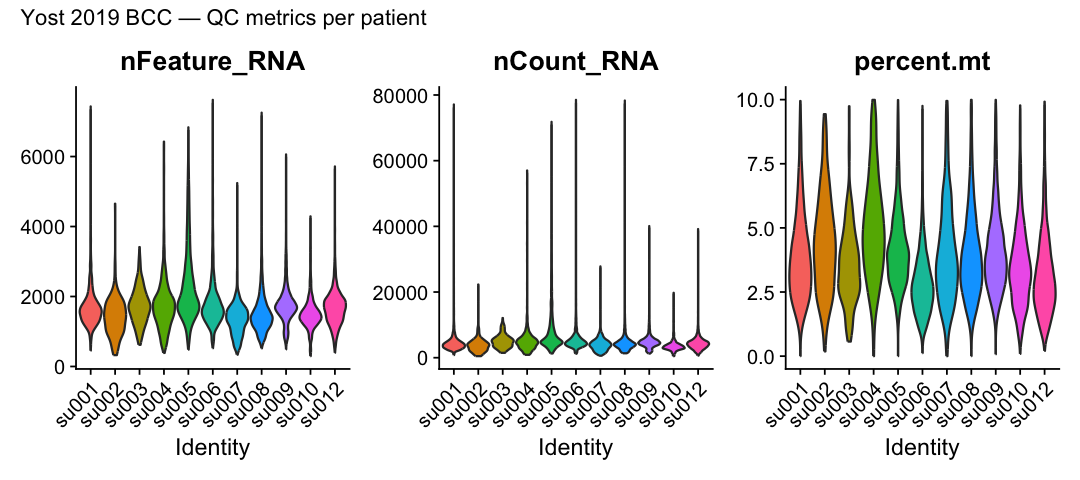

In [9]:
if (use_yost) {
  # Basic QC
  yost[["percent.mt"]] <- PercentageFeatureSet(yost, pattern = "^MT-")

  VlnPlot(yost, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"),
          ncol = 3, pt.size = 0, group.by = "patient") +
    plot_annotation(title = "Yost 2019 BCC — QC metrics per patient")
}

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


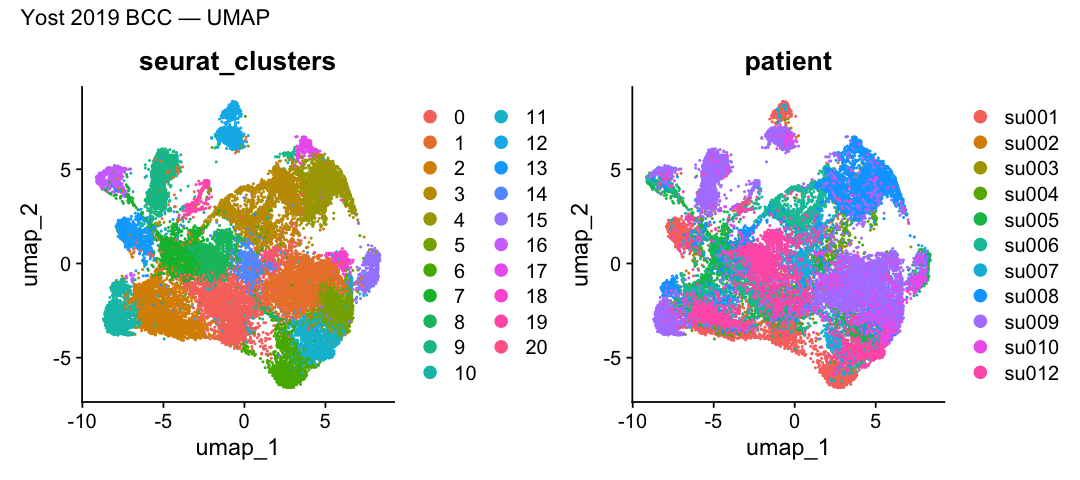

In [10]:
if (use_yost) {
  # Standard preprocessing (mirrors NB01 logic)
  yost <- subset(yost, subset = nFeature_RNA > 200 & nFeature_RNA < 4000 & percent.mt < 25)
  yost <- NormalizeData(yost, verbose = FALSE)
  yost <- FindVariableFeatures(yost, nfeatures = n_hvg, verbose = FALSE)
  yost <- ScaleData(yost, features = VariableFeatures(yost), verbose = FALSE)
  yost <- RunPCA(yost, npcs = 50, verbose = FALSE)
  yost <- FindNeighbors(yost, dims = 1:30, verbose = FALSE)
  yost <- FindClusters(yost, resolution = 0.5, verbose = FALSE)
  yost <- RunUMAP(yost, dims = 1:30, return.model = TRUE, verbose = FALSE)

  DimPlot(yost, group.by = c("seurat_clusters", "patient"), ncol = 2) +
    plot_annotation(title = "Yost 2019 BCC — UMAP")
}

Exhaustion markers present: PDCD1, ENTPD1, HAVCR2, LAG3, TIGIT, TOX, GZMB


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


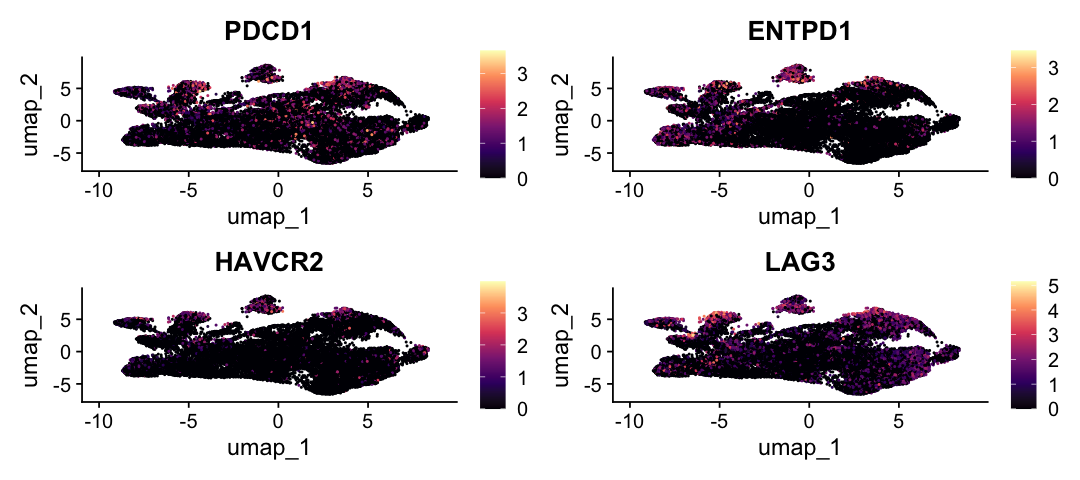

In [11]:
if (use_yost) {
  # Highlight exhaustion markers — CD39 (ENTPD1) + PD-1 (PDCD1) are key markers
  # for tumour-reactive exhausted CD8+ TIL in this dataset
  ex_markers <- c("PDCD1", "ENTPD1", "HAVCR2", "LAG3", "TIGIT", "TOX", "GZMB")
  ex_present <- intersect(ex_markers, rownames(yost))
  cat(sprintf("Exhaustion markers present: %s\n", paste(ex_present, collapse = ", ")))

  if (length(ex_present) > 0) {
    FeaturePlot(yost, features = ex_present[1:min(4, length(ex_present))],
                ncol = 2, reduction = "umap") &
      scale_colour_viridis_c(option = "magma")
  }
}

In [12]:
if (use_yost) {
  # ── Patient-based leave-one-out split ────────────────────────────────────
  # Holding out ALL cells from one patient as the query and using the
  # remaining patients as the reference avoids data leakage: cells from
  # the same patient cannot appear in both train and test sets.
  all_patients <- sort(unique(yost$patient))
  cat(sprintf("All patients (%d): %s
",
              length(all_patients), paste(all_patients, collapse = ", ")))

  # If query_patient is blank or not found, pick one randomly
  qp <- trimws(query_patient)
  if (nchar(qp) == 0 || !(qp %in% all_patients)) {
    set.seed(random_seed)
    qp <- sample(all_patients, 1L)
    cat(sprintf("No valid query_patient specified — randomly selected: %s
", qp))
  } else {
    cat(sprintf("Using specified query patient: %s
", qp))
  }

  # Split into reference (all other patients) and query (held-out patient)
  ref_cells   <- colnames(yost)[yost$patient != qp]
  query_cells <- colnames(yost)[yost$patient == qp]
  ref   <- subset(yost, cells = ref_cells)
  query <- subset(yost, cells = query_cells)

  cat(sprintf("Reference: %d cells from %d patients (all except %s)
",
              ncol(ref), length(unique(ref$patient)), qp))
  cat(sprintf("Query    : %d cells from patient %s
", ncol(query), qp))

  if ("cluster" %in% colnames(query@meta.data)) {
    cat("Held-out patient cell type distribution:
")
    print(table(query$cluster))
  }

  # Save
  dir.create(dirname(output_reference), showWarnings = FALSE, recursive = TRUE)
  saveRDS(ref,   file = output_reference)
  cat(sprintf("
Reference saved -> %s  (%d cells)
", output_reference, ncol(ref)))

  saveRDS(query, file = output_query)
  cat(sprintf("Query     saved -> %s  (%d cells)
", output_query, ncol(query)))
}


All patients (11): su001, su002, su003, su004, su005, su006, su007, su008, su009, su010, su012
Using specified query patient: su001
Reference: 27626 cells from 10 patients (all except su001)
Query    : 4905 cells from patient su001
Held-out patient cell type distribution:

CD8_act CD8_eff  CD8_ex CD8_mem   Naive     Tfh    Th17   Tregs 
     21      34     350    1360     162     816    1112    1050 

Reference saved -> data/cca/reference_no_su001.rds  (27626 cells)
Query     saved -> data/cca/query_su001.rds  (4905 cells)


## Part B — Caushi et al. 2021 NSCLC (GSE176021)

**Paper:** Caushi JX, Zhang J, Ji Z, et al. *Transcriptional programs of neoantigen-specific TIL in anti-PD-1-treated lung cancers.* Nature 2021;596:126–132. PMID: 34290408

**Why this dataset provides ground truth:**  
The **MANAFEST assay** (Mutation Associated NeoAntigen Functional Expansion of Specific T cells) identifies T cell clones that respond to patient-specific neoantigens *in vitro*. The CDR3 sequences of MANAFEST-positive clones were then tracked back into the tumour scRNA-seq data — giving us a binary label: `is_neoantigen_reactive = TRUE/FALSE` per clonotype.  

GEO directly provides a pre-processed, annotated CD8 Seurat object: `GSE176021_CD8_annotations.rds.gz`.  
The `annotation` column distinguishes MANA-specific from virus-specific and bystander TIL.

**Files used:**
- `GSE176021_CD8_annotations.rds.gz` — annotated CD8+ TIL Seurat object (directly usable)
- Annotation column identifies MANA-specific vs. flu-specific vs. bystander clonotypes

In [13]:
if (use_caushi) {
  geo_base2 <- "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE176nnn/GSE176021/suppl"

  caushi_rds_gz <- cached_download(
    sprintf("%s/GSE176021_CD8_annotations.rds.gz", geo_base2),
    file.path(cache_dir, "GSE176021_CD8_annotations.rds.gz")
  )
  cat("Caushi 2021 CD8 Seurat object downloaded.\n")
}

Cached: GSE176021_CD8_annotations.rds.gz
Caushi 2021 CD8 Seurat object downloaded.


In [14]:
if (use_caushi) {
  # Decompress and load .rds.gz (GSE176021 CD8 annotation data.frame)
  caushi_rds <- file.path(cache_dir, "GSE176021_CD8_annotations.rds")
  if (!file.exists(caushi_rds)) {
    R.utils::gunzip(caushi_rds_gz, destname = caushi_rds, remove = FALSE)
  }
  cd8_caushi <- readRDS(caushi_rds)  # data.frame: nCount_RNA, nFeature_RNA, barcode, imid, CellType, UMAP_1, UMAP_2

  cat(sprintf("Caushi CD8 annotation table: %d cells x %d columns\n",
              nrow(cd8_caushi), ncol(cd8_caushi)))
  cat("Columns: ", paste(colnames(cd8_caushi), collapse = ", "), "\n")
}


Caushi CD8 annotation table: 235851 cells x 7 columns
Columns:  nCount_RNA, nFeature_RNA, barcode, imid, CellType, UMAP_1, UMAP_2 


In [15]:
if (use_caushi) {
  # Explore CellType annotation column
  annot_col <- intersect(
    c("CellType", "annotation", "specificity", "TCR_group", "cluster", "cell_type"),
    colnames(cd8_caushi)
  )[1]

  if (!is.na(annot_col)) {
    cat(sprintf("Using annotation column: '%s'\n", annot_col))
    print(table(cd8_caushi[[annot_col]]))
  } else {
    cat("Annotation column not found. Showing all columns:\n")
    print(summary(cd8_caushi))
  }
}


Using annotation column: 'CellType'

Stem-like memory      Effector(I)     Effector(II)    Effector(III) 
            6706            38904            38618             6385 
          TRM(I)          TRM(II)         TRM(III)          TRM(IV) 
           31028            36833             5470            23896 
          TRM(V)          TRM(VI)    Proliferating             MAIT 
           14811             9990             1587             4662 
       CD4CD8(I)       CD4CD8(II) 
           14013             2948 


In [16]:
if (use_caushi) {
  # Create ground-truth tumour reactivity label from CellType
  # Effector and TRM cells are associated with tumour reactivity in CD8 TIL literature
  # Stem-like memory / MAIT / CD4CD8 are bystander-like controls
  annot_col <- intersect(
    c("CellType", "annotation", "specificity", "TCR_group", "cluster", "cell_type"),
    colnames(cd8_caushi)
  )[1]

  if (!is.na(annot_col)) {
    labels <- cd8_caushi[[annot_col]]
    cd8_caushi$is_tumor_reactive <- grepl(
      "Effector|TRM|Prolifer",
      labels, ignore.case = TRUE
    )
    cat("Tumour-reactive proxy labels (TRUE = Effector/TRM/Proliferating):\n")
    print(table(cd8_caushi$is_tumor_reactive))
  } else {
    cd8_caushi$is_tumor_reactive <- FALSE
  }
}


Tumour-reactive proxy labels (TRUE = Effector/TRM/Proliferating):

 FALSE   TRUE 
 28329 207522 


In [17]:
if (use_caushi) {
  library(dplyr)
  # Build cell-level table for NB04 ground truth (no clonotype column — group by imid = patient)
  clon_df <- cd8_caushi %>%
    group_by(clonotype_id = imid) %>%
    summarise(
      clone_size        = n(),
      n_reactive_cells  = sum(is_tumor_reactive, na.rm = TRUE),
      .groups           = "drop"
    ) %>%
    mutate(
      is_tumor_reactive = n_reactive_cells > 0,
      clone_frequency   = clone_size / nrow(cd8_caushi),
      patient           = clonotype_id
    )

  cat(sprintf("Caushi clonotype table: %d rows\n", nrow(clon_df)))

  # Save annotated cell table
  annotated_rds_path <- file.path(data_dir, "caushi2021_cd8_annotated.rds")
  saveRDS(cd8_caushi, annotated_rds_path)
  cat("Saved:", annotated_rds_path, "\n")

  # Save clonotype CSV for NB04
  write.csv(clon_df, output_caushi_clonotypes, row.names = FALSE)
  cat("Saved:", output_caushi_clonotypes, "\n")
}


Caushi clonotype table: 17 rows
Saved: data/caushi2021_cd8_annotated.rds 
Saved: data/caushi2021_ranked_clonotypes.csv 


## Summary

| Output | Used by | Description |
|--------|---------|-------------|
| `data/yost2019_bcc_query.rds` | NB01–NB03 | BCC TIL Seurat object (scRNA-seq + TCR) |
| `data/yost2019_bcc_tcr.rds` | NB03 | Raw TCR clonotype table for `scRepertoire` |
| `data/caushi2021_cd8_annotated.rds` | NB04 | CD8 Seurat object with MANA labels |
| `data/caushi2021_ranked_clonotypes.csv` | NB04 | Clonotype table with `is_tumor_reactive` ground truth |

**Next steps:**
1. Run **NB01** with `query_path = 'data/yost2019_bcc_query.rds'` to skip CellRanger loading
2. Run **NB03** — replace synthetic clonotypes with `yost2019_bcc_tcr.rds` via `scRepertoire`
3. Run **NB04** — train RF on `caushi2021_ranked_clonotypes.csv` with true `is_tumor_reactive` labels

> **Data provenance note:** Yost et al. and Caushi et al. data are published under standard GEO data sharing agreements. Please cite the original papers in any derived work.